### Global Forest Change 2000-2023 Data from University of Maryland in partnership with Global Forest Warch (GFW) 
- treecover2000.tif:
    - tree canopy cover for the year 2000, defined as canopy closure for all vegetation taller than 5 meters. The values range from 0 to 100, representing the percentage of tree cover.
- gain.tif:
    - forest gain during the period 2000-2012. Values are either 1 (forest gain) or 0 (no gain).
- lossyear.tif:
    - represents the year of forest loss event, encoded as values ranging from 1 to 20, corresponding to the years 2001-2023.
- datamask.tif:
    -  three values: 0 (no data), 1 (mapped land surface), and 2 (persistent water bodies) based on the period 2000-2012.
- first.tif:
    - reference multispectral image composite from the first available year, typically 2000. If no cloud-free observations were available for 2000, the image is from the closest year within 1999-2012.
- last.tif:
    - reference multispectral image composite from the last available year, typically 2023. If no cloud-free observations were available for 2023, the image is from the closest year.

In [7]:
!pip install patchify

  Using cached patchify-0.2.3-py3-none-any.whl.metadata (3.0 kB)
Using cached patchify-0.2.3-py3-none-any.whl (6.6 kB)


In [8]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import PIL
from PIL import Image
import rasterio
from rasterio.windows import Window
import cv2
import skimage.feature
from skimage.feature import local_binary_pattern
from scipy.ndimage import gaussian_filter
from scipy.ndimage import binary_dilation

from patchify import patchify

## Function to create 400 by 400 patches and save as PNG

#### current set up
1. define name of image with image_name variable  - 40N or 50N
2. Adjust image path and mask path filenames
3. Run function for treecover, first, image, last image, and lossyear for 40N and 50N


In [10]:
# Split image into 400 x 400 pixel sub-images based on mask values indicating presence of land, save to directory.

def process_and_save_chunks_as_png(image_path, mask_path, output_dir):
    with rasterio.open(image_path) as src:
        # dynamically read the number of bands
        num_bands = src.count
        band_indices = list(range(1, num_bands + 1))

        with rasterio.open(mask_path) as mask_src:
            chunk_size = 400
            num_chunks = 100  # since 40,000 / 400 = 100

            for i in range(num_chunks):
                for j in range(num_chunks):
                    window = Window(j * chunk_size, i * chunk_size, chunk_size, chunk_size)
                    mask_chunk = mask_src.read(1, window=window)
                    image_chunk = src.read(band_indices, window=window)  # read all available bands

                    # calculate the average of the mask chunk
                    average_mask_value = np.mean(mask_chunk)

                    # check the condition for the average mask value
                    if 0.1 <= average_mask_value <= 1:
                        save_image_chunk_as_png(image_chunk, num_bands, i, j, output_dir,image_name='50N')

def save_image_chunk_as_png(chunk, num_bands, i, j, output_dir, image_name):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    if num_bands == 1:
        image = Image.fromarray(chunk[0])  # since chunk will be (1, height, width)
    else:
        image = Image.fromarray(np.moveaxis(chunk, 0, -1))
    filename = os.path.join(output_dir, f"{image_name}_{i}_{j}.png")
    image.save(filename, format='PNG')

## Save tree cover labels

In [154]:
# # Run through once to save tree cover labels
# image_path = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/original_images/treecover2000_50N_130W.tif"
# mask_path = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/original_images/datamask_50N_130W.tif"
# output_dir = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/tree_cover_labels/"
# process_and_save_chunks_as_png(image_path, mask_path, output_dir)

# # Now run through to save image itself
# image_path = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/original_images/first_50N_130W.tif"
# mask_path = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/original_images/datamask_50N_130W.tif"
# output_dir = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/first_image/"
# process_and_save_chunks_as_png(image_path, mask_path, output_dir)

# # Save 2023 image features
# image_path = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/original_images/last_50N_130W.tif"
# mask_path = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/original_images/datamask_50N_130W.tif"
# output_dir = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/last_image"
# process_and_save_chunks_as_png(image_path, mask_path, output_dir)

# breakdown loss image
image_path = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/original_images/lossyear_50N_130W.tif"
mask_path = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/original_images/datamask_50N_130W.tif"
output_dir = '/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/loss_images'
process_and_save_chunks_as_png(image_path, mask_path, output_dir)


## Applying Pre-Processing Techniques

In [199]:
# This code takes raw feature images (4 channels) as input
# Applies pre-processing techniques, then saves the images into a new directory.

def calculate_ndvi(image_path):
    # calculate NDVI

    with Image.open(image_path) as img:
        img_array = np.array(img)
        
        red = img_array[:, :, 0].astype(float)
        nir = img_array[:, :, 1].astype(float)
        
        # calculate NDVI
        numerator = nir - red
        denominator = nir + red
        # avoid division by zero using np.where to set small denominators to a small positive value
        denominator = np.where(denominator == 0, 0.0001, denominator)
        ndvi = numerator / denominator
        
        # handle potential NaNs and Infs in the NDVI calculation
        ndvi = np.nan_to_num(ndvi, nan=0.0, posinf=0.0, neginf=0.0)
        
        # normalize NDVI to the range 0 to 255 for image saving
        ndvi_min = ndvi.min()
        ndvi_max = ndvi.max()
        if ndvi_max - ndvi_min > 0:
            ndvi_normalized = 255 * (ndvi - ndvi_min) / (ndvi_max - ndvi_min)
        else:
            ndvi_normalized = np.zeros_like(ndvi)  # all values are the same
        
        ndvi_normalized = ndvi_normalized.astype(np.uint8)
        
        return ndvi_normalized

def apply_gaussian_filter(ndvi_array, sigma=1):
    # apply a Gaussian filter to the NDVI array.
    return gaussian_filter(ndvi_array, sigma=sigma)

def process_images_in_directory(source_directory, target_directory, sigma=1):
    # process each satellite image in the directory to calculate NDVI, smooth it, and save the result.

    if not os.path.exists(target_directory):
        os.makedirs(target_directory)

    for file_name in os.listdir(source_directory):
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            source_path = os.path.join(source_directory, file_name)
            target_path = os.path.join(target_directory, file_name)
            
            # pre-processing 1
            # calculate NDVI
            ndvi = calculate_ndvi(source_path)
            
            # pre-processing 2
            # apply Gaussian filter
            smoothed_ndvi = apply_gaussian_filter(ndvi, sigma=sigma)
            
            Image.fromarray(smoothed_ndvi).save(target_path)

source_directory = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/last_image/"
target_directory = "/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/preprocessed_last/"

process_images_in_directory(source_directory, target_directory, sigma = 2)

## Create Forest Cover Binary Mask

In [194]:
def create_forest_cover_mask(label_image, thereshold):
    """
    Creates a mask from the label image.

    Returns:
    - mask (numpy.ndarray): Output mask with classes:
      Class 1: Pixel > 80% tree cover.
      Class 0: Pixel <= 80% tree cover.
    """
    mask = np.zeros_like(label_image, dtype=np.uint8) 

    mask[label_image > thereshold] = 1
    
    return mask

def process_images_in_folder(input_folder, output_folder):
    """
    Processes all label images in the input folder, creates masks, and saves them to the output folder.
    
    Args:
    - input_folder (str): Path to the input folder containing label images.
    - output_folder (str): Path to the output folder to save masks.
    """
    # ensure the output folder exists
    os.makedirs(output_folder, exist_ok=True)
    
    # iterate through each file in the input folder
    for file_name in tqdm(os.listdir(input_folder)):
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
            file_path = os.path.join(input_folder, file_name)
            
            try:
                # read the label image
                with Image.open(file_path) as img:
                    label_image = np.array(img)
                
                
                # check if the image was successfully read
                if label_image is None:
                    print(f"Warning: Failed to read {file_path}. Skipping this file.")
                    continue
                
                # create the mask
                mask = create_forest_cover_mask(label_image,thereshold=threshold)
                
                # save the mask to the output folder
                output_path = os.path.join(output_folder, file_name)
                cv2.imwrite(output_path, mask)
                
            except Exception as e:
                print(f"Error processing {file_path}: {str(e)}")
                continue


# create masks from tree cover labels
input_folder = '/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/tree_cover_labels/'
output_folder = '/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/masks/0_masks/'
threshold=0
process_images_in_folder(input_folder, output_folder)


100%|██████████| 1999/1999 [00:07<00:00, 275.29it/s]


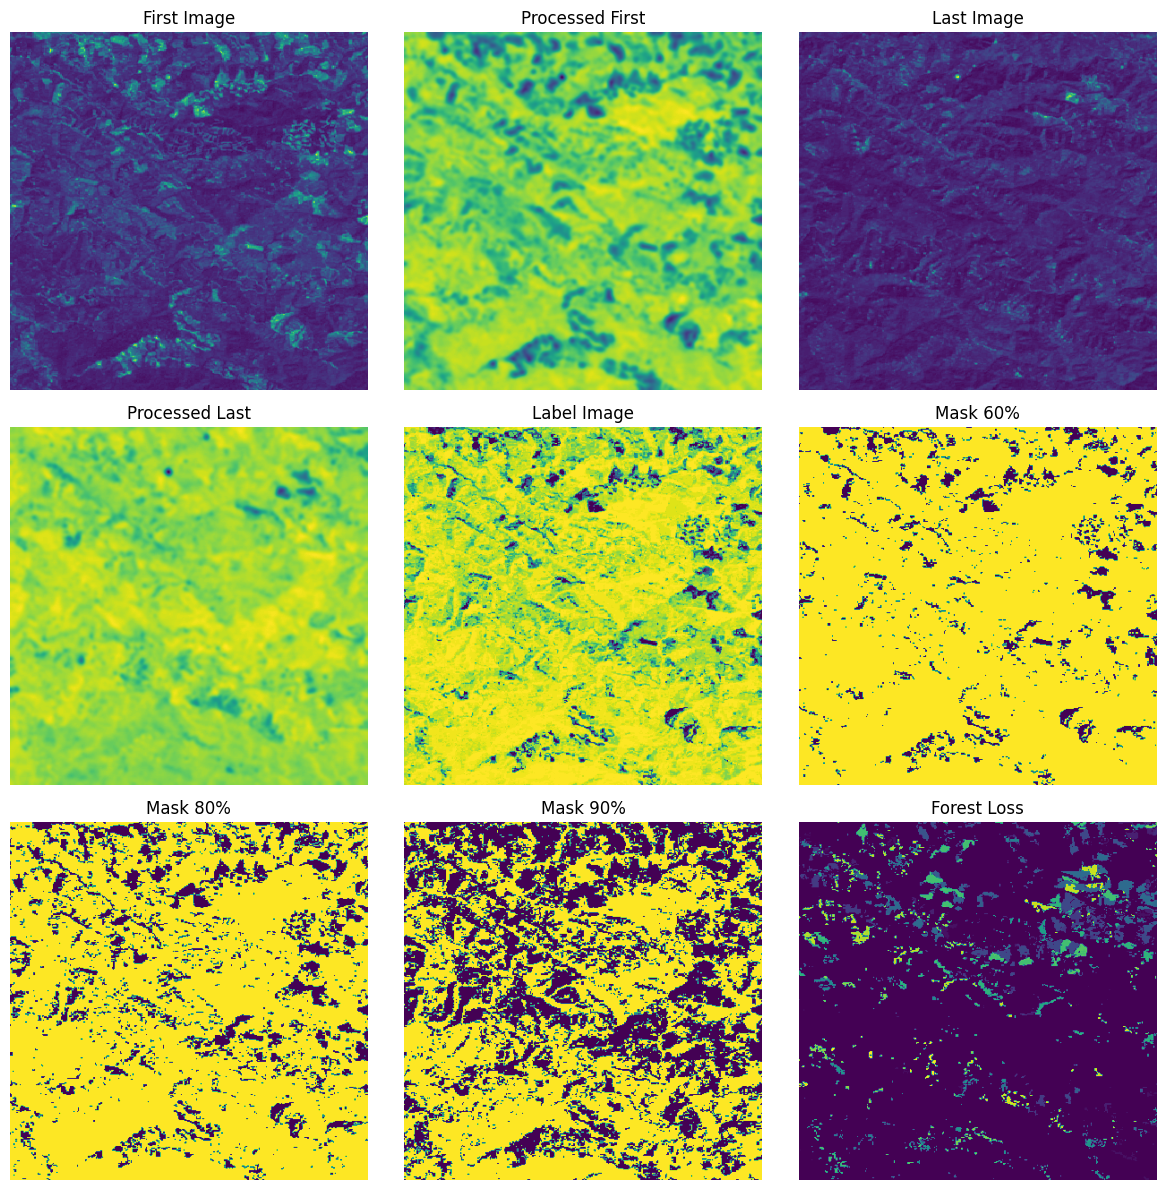

In [219]:
import matplotlib.image as mpimg
first_image = '/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/first_image/40N_5_63.png'
pre_first = '/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/preprocessed_first/40N_5_63.png'

last_image = '/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/last_image/40N_5_63.png'
pre_last = '/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/preprocessed_last/40N_5_63.png'

label_path = '/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/tree_cover_labels/40N_5_63.png'
mask60_path = '/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/masks/60_masks/40N_5_63.png'
mask80_path = '/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/masks/80_masks/40N_5_63.png'
mask90_path = '/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/masks/90_masks/40N_5_63.png'

loss_path = '/Users/Geronimowalker/Desktop/MIDS/Capstone/GFC_images/split_images/loss_images/40N_5_63.png'

# Load the images to visualize
first_img = mpimg.imread(first_image)
pre_first_img = mpimg.imread(pre_first)

last_img = mpimg.imread(last_image)
pre_last_img = mpimg.imread(pre_last)

label_img = mpimg.imread(label_path)
mask60_img = mpimg.imread(mask60_path)
mask80_img = mpimg.imread(mask80_path)
mask90_img = mpimg.imread(mask90_path)

loss_img = mpimg.imread(loss_path)


fig, axs = plt.subplots(3, 3, figsize=(12, 12))


titles = ['First Image', 'Processed First', 
          'Last Image','Processed Last', 
          'Label Image',
          'Mask 60%', 'Mask 80%', 'Mask 90%',
          'Forest Loss']

# Select images to plot
images = [first_img[:,:,3], pre_first_img, last_img[:,:,3], pre_last_img, label_img, mask60_img, mask80_img, mask90_img, loss_img]


for i, ax in enumerate(axs.flat):
    if i < len(images):
        ax.imshow(images[i])
        ax.set_title(titles[i])
        ax.axis('off')  
    else:
        ax.axis('off')  


plt.tight_layout()
plt.show()